# Prep the scRNA-seq and Bulk RNA-seq

scRNA-seq: 
* Chromium Single-Cell 3′ Reagent Kit v. 2.0 (10x Genomics) 
* sequenced on Illumina HiSeq 4000 (Jussi Taipale Lab, Karolinska Institute, Sweden), HiSeq 2500, and NovaSeq 6000 instruments 
* Used Cell Ranger (version 3.1.0)
* GRCh38.d1.vd1 reference genome with GENCODE v25 annotation

In [2]:
# Single-cell (raw counts but QCed)
library(data.table)
library(dplyr)
library(Matrix)
#BiocManager::install("muscat") # for pseudobulking
library(muscat)
library(SingleCellExperiment)
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-apple-darwin20
Running under: macOS Ventura 13.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.4-x86_64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.4-x86_64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.0

locale:
[1] C

time zone: America/Denver
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] SingleCellExperiment_1.26.0 SummarizedExperiment_1.34.0
 [3] Biobase_2.64.0              GenomicRanges_1.56.2       
 [5] GenomeInfoDb_1.40.1         IRanges_2.38.1             
 [7] S4Vectors_0.42.1            BiocGenerics_0.50.0        
 [9] MatrixGenerics_1.16.0       matrixStats_1.5.0          
[11] muscat_1.18.0               Matrix_1.7-2               
[13] dplyr_1.1.4                 data.table_1.18.0          

loaded via a namespace (and not attache

## 1. Pseudobulk scRNAseq

In [ ]:

meta <- fread("../../data/counts/GSE165897_cellInfo_HGSOC.tsv.gz")
meta[1:2,]

sc_counts <- fread("../../data/counts/GSE165897_UMIcounts_HGSOC.tsv.gz")

Warning message:
"package 'data.table' was built under R version 4.4.1"

Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'Matrix' was built under R version 4.4.1"
Warning message in check_dep_version(dep_pkg = "TMB"):
"package version mismatch: 
glmmTMB was built with TMB package version 1.9.15
Current TMB package version is 1.9.16
Please re-install glmmTMB from source or restore original 'TMB' package (see '?reinstalling' for more information)"
Cargando paquete requerido: SummarizedExperiment

Cargando paquete requerido: MatrixGenerics

Cargando paquete requerido: matrixStats

Warning message:
"package 'matrixStats' was built under R version 4.4.1"

Adjuntando el paquete: 'matrixStats'


The following object is masked f

cell,sample,patient_id,treatment_phase,anatomical_location,cell_type,cell_subtype,nCount_RNA,nFeature_RNA,percent.mt
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
AAACCTGCAGGTTTCA-EOC372_pPer,EOC372_primary_Peritoneum,EOC372,treatment-naive,Peritoneum,EOC,EOC_C11,33538,5704,4.561989
AAACCTGGTCCGAATT-EOC372_pPer,EOC372_primary_Peritoneum,EOC372,treatment-naive,Peritoneum,EOC,EOC_C12,17830,3198,11.648906


In [2]:
library(data.table)
library(Matrix)
library(SingleCellExperiment)

# chunk boundaries (your original indices)
index_first_list  <- c(1, 5001, 10001, 15001, 20001, 25001, 30001)
index_second_list <- c(5000, 10000, 15000, 20000, 25000, 30000, 32847)

cells <- colnames(sc_counts)[-1]       # fixed list of cells (columns)
meta_filt <- meta[match(cells, meta$cell)]  # ordered metadata

# ---- storage objects for final output ----
full_mat <- NULL  # dgCMatrix, will grow by rbind
genes_all <- character()  # final rownames

for (i in seq_along(index_first_list)) {

    message("Processing chunk ", i)

    # subset gene rows for this chunk
    sc_chunk <- sc_counts[index_first_list[i]:index_second_list[i], ]
    genes <- sc_chunk[[1]]

    # melt to long format (suppress zeros)
    dt_long <- melt(
        sc_chunk,
        id.vars = "V1",
        variable.name = "cell",
        value.name = "count"
    )[count > 0]

    rm(sc_chunk); gc()

    # build sparse chunk matrix
    chunk_mat <- sparseMatrix(
        i = match(dt_long$V1, genes),
        j = match(dt_long$cell, cells),
        x = dt_long$count,
        dims = c(length(genes), length(cells)),
        dimnames = list(genes, cells)
    )

    rm(dt_long); gc()

    # append to final sparse matrix
    if (is.null(full_mat)) {
        full_mat <- chunk_mat
    } else {
        full_mat <- rbind(full_mat, chunk_mat)
    }

    genes_all <- c(genes_all, genes)

    rm(chunk_mat); gc()
}

# ---- build final SCE object ----

sce <- SingleCellExperiment(
    assays = list(counts = full_mat),
    colData = meta_filt
)

# make sure sample is factor
sce$sample <- as.factor(sce$sample)
sce$cell_subtype <- as.factor(sce$cell_subtype)

sce


Processing chunk 1

Processing chunk 2

Processing chunk 3

Processing chunk 4

Processing chunk 5

Processing chunk 6

Processing chunk 7



class: SingleCellExperiment 
dim: 32847 51786 
metadata(0):
assays(1): counts
rownames(32847): RP11-34P13.7 RP11-34P13.8 ... MT-TT MT-TP
rowData names(0):
colnames(51786): AAACCTGCAGGTTTCA-EOC372_pPer
  AAACCTGGTCCGAATT-EOC372_pPer ... TTTGTCACATTGGGCC-EOC443_pOme
  TTTGTCAGTAAGGATT-EOC443_pOme
colData names(10): cell sample ... nFeature_RNA percent.mt
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [4]:
names(colData(sce))

[1] "cell"                "sample"              "patient_id"         
 [4] "treatment_phase"     "anatomical_location" "cell_type"          
 [7] "cell_subtype"        "nCount_RNA"          "nFeature_RNA"       
[10] "percent.mt"

In [ ]:
saveRDS(sce, file="../../data/final_counts/GSE165897_HGSOC_SCEobject.rds")

In [2]:

#index_list <- c(1:10000, 10001:20000, 20001:32847)
index_first_list <- c(1, 5001, 10001, 15001, 20001, 25001, 30001)
index_second_list <- c(5000, 10000, 15000, 20000, 25000, 30000, 32847)
pb_sample_list = list()
pb_sample_subtype_list = list()
cells <- colnames(sc_counts)[-1]

for (i in c(1, 2, 3, 4, 5, 6, 7)) {
	sc_counts_filt <- sc_counts[index_first_list[[i]]:index_second_list[[i]],] #10000
	print(dim(sc_counts_filt))
	# long format
	dt_long <- melt(
		sc_counts_filt,
		id.vars = "V1",
		variable.name = "cell",
		value.name = "count"
	)[count > 0]

	genes <- sc_counts_filt$V1
	# remove from memory
	rm(sc_counts_filt)
	gc()

	# create a sparse matrix
	count_mat <- sparseMatrix(
    i = match(dt_long$V1, genes),
    j = match(dt_long$cell, cells),
    x = dt_long$count,
    dims = c(length(genes), length(cells)),
    dimnames = list(genes, cells)
	)
	# remove from memory
	rm(dt_long)
	gc()

	meta_filt <- meta[meta$cell %in% cells,]
	meta_filt = meta_filt[match(cells, meta_filt$cell)]
	# make a sc dataset to use for pseudobulking
	sce <- SingleCellExperiment(
		assays = list(counts = count_mat),
		colData = meta_filt
	)
	sce$sample <- as.factor(sce$sample)

	# pseudobulk by sample
	pb_sample_list[[i]] <- aggregateData(
		x= sce,
		assay = "counts",
		fun = "sum",
		by = "sample", 
		verbose=TRUE
	)
	assayNames(pb_sample_list[[i]]) <- "counts"

	# pseudobulk by sample × subtype
	pb_sample_subtype_list[[i]] <- aggregateData(
	    sce,
	    assay = "counts",
	    fun = "sum",
	    by = c("sample", "cell_subtype")
	)
}

[1]  5000 51787
[1]  5000 51787
[1]  5000 51787
[1]  5000 51787
[1]  5000 51787
[1]  5000 51787
[1]  2847 51787


In [3]:
# combine the pseudobulked data
pb_sample <- do.call(rbind, lapply(pb_sample_list, function(x) assay(x, "counts")) )

pb_sample_subtype_list_save <- list()
for (aname in assayNames(pb_sample_subtype_list[[1]])) {
	pb_sample_subtype_list_save[[aname]] <- do.call(rbind, lapply(pb_sample_subtype_list, function(x) assay(x, aname)) )
}


In [4]:
assayNames(pb_sample_subtype_list[[1]])

# iterate through assay names

[1] "EOC1005_interval_Tumor"     "EOC1005_primary_Peritoneum"
 [3] "EOC136_interval_Omentum"    "EOC136_primary_Mesentery"  
 [5] "EOC153_interval_Omentum"    "EOC153_primary_Omentum"    
 [7] "EOC227_interval_Omentum"    "EOC227_primary_Omentum"    
 [9] "EOC349_interval_Omentum"    "EOC349_primary_Peritoneum" 
[11] "EOC372_interval_Peritoneum" "EOC372_primary_Peritoneum" 
[13] "EOC3_interval_Omentum"      "EOC3_primary_Peritoneum"   
[15] "EOC443_interval_Omentum"    "EOC443_primary_Omentum"    
[17] "EOC540_interval_Omentum"    "EOC540_primary_Omentum"    
[19] "EOC733_interval_Omentum"    "EOC733_primary_Peritoneum" 
[21] "EOC87_interval_Omentum"     "EOC87_primary_Peritoneum"

In [5]:
dim(pb_sample)
pb_sample[1:4,]
length(unique(colnames(pb_sample)))
length(unique(rownames(pb_sample)))

[1] 32847    22

,EOC1005_interval_Tumor,EOC1005_primary_Peritoneum,EOC136_interval_Omentum,EOC136_primary_Mesentery,EOC153_interval_Omentum,EOC153_primary_Omentum,EOC227_interval_Omentum,EOC227_primary_Omentum,EOC349_interval_Omentum,EOC349_primary_Peritoneum,...,EOC3_interval_Omentum,EOC3_primary_Peritoneum,EOC443_interval_Omentum,EOC443_primary_Omentum,EOC540_interval_Omentum,EOC540_primary_Omentum,EOC733_interval_Omentum,EOC733_primary_Peritoneum,EOC87_interval_Omentum,EOC87_primary_Peritoneum
RP11-34P13.7,1,3,9,3,2,3,7,3,6,4,...,3,6,9,8,0,5,2,3,1,4
RP11-34P13.8,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1
CICP27,0,0,0,1,1,0,0,0,1,1,...,0,0,1,0,1,0,0,0,0,1
RP11-34P13.15,2,6,13,7,4,0,10,3,3,0,...,2,7,17,102,0,8,4,1,1,1


[1] 22

[1] 32847

In [6]:
names(pb_sample_subtype_list_save)
dim(pb_sample_subtype_list_save[[1]])
pb_sample_subtype_list_save[[1]][1:4,]
length(unique(colnames(pb_sample_subtype_list_save[[1]])))
length(unique(rownames(pb_sample_subtype_list_save[[1]])))

[1] "EOC1005_interval_Tumor"     "EOC1005_primary_Peritoneum"
 [3] "EOC136_interval_Omentum"    "EOC136_primary_Mesentery"  
 [5] "EOC153_interval_Omentum"    "EOC153_primary_Omentum"    
 [7] "EOC227_interval_Omentum"    "EOC227_primary_Omentum"    
 [9] "EOC349_interval_Omentum"    "EOC349_primary_Peritoneum" 
[11] "EOC372_interval_Peritoneum" "EOC372_primary_Peritoneum" 
[13] "EOC3_interval_Omentum"      "EOC3_primary_Peritoneum"   
[15] "EOC443_interval_Omentum"    "EOC443_primary_Omentum"    
[17] "EOC540_interval_Omentum"    "EOC540_primary_Omentum"    
[19] "EOC733_interval_Omentum"    "EOC733_primary_Peritoneum" 
[21] "EOC87_interval_Omentum"     "EOC87_primary_Peritoneum"

[1] 32847    27

,B-cells,CAF-1,CAF-2,CAF-3,DC-1,DC-2,EOC_C1,EOC_C10,EOC_C11,EOC_C12,...,EOC_C9,Endothelial,ILC,Macrophages,Mast-cells,Mesothelial,NK,Plasma-cells,T-cells,pDC
RP11-34P13.7,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
RP11-34P13.8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CICP27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RP11-34P13.15,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


[1] 27

[1] 32847

In [7]:
## save the files
# save the pb_sample_list as an RDS object since it hosts the different ones 

saveRDS(pb_sample_subtype_list_save, file="../../data/counts/scRNAseq_pseudobulked_by_sample_and_subtype.rds")
saveRDS(pb_sample, file="../../data/counts/scRNAseq_pseudobulked_by_sample.rds")

In [8]:
# remove the unneeded objects to free up memory
rm(sc_counts)
rm(count_mat)
rm(pb_sample_list)
rm(pb_sample_subtype_list)
gc()

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,9181327,490.4,13774211,735.7,NA,13774211,735.7
Vcells,51692655,394.4,1537149850,11727.6,16384,1921384159,14659.0


## 2. Harmonize the names (gene and sample names)
Between RNA-seq and scRNA-seq

In [ ]:
# read in the RNA-seq data
bulk_counts <- fread("../../data/counts/EGA_str_gtf_genes.txt")
bulk_counts[1:2,]

Geneid,Chr,Start,End,Strand,Length,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205.sorted.bam,...,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214.sorted.bam,/scratch/Shares/clauset/Clauset_ABNexus/RNAseq_flow_out/EGA_8.27/mapped/bams/EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,5,10,2,...,0,1,0,1,5,3,3,4,5,3
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,17,324,295,126,...,6,16,14,11,22,44,169,251,532,338


### A. Consider shared genes

In [10]:
length(unique(meta$sample))
dim(bulk_counts)
dim(pb_sample)


length(intersect(bulk_counts$Geneid, rownames(pb_sample)))

lost_in_bulk <- setdiff(rownames(pb_sample), bulk_counts$Geneid)
lost_in_sc <- setdiff(bulk_counts$Geneid, rownames(pb_sample))
cat("\nLost in Bulk:", length(lost_in_bulk))
cat("\nLost in SC:", length(lost_in_sc))
lost_in_bulk[1:20]
lost_in_sc[1:20]

[1] 22

[1] 49771   122

[1] 32847    22

[1] 18985


Lost in Bulk: 13862
Lost in SC: 30786

[1] "RP11-34P13.7"  "RP11-34P13.8"  "CICP27"        "RP11-34P13.15"
 [5] "RP11-34P13.13" "FO538757.1"    "AP006222.2"    "RP4-669L17.2" 
 [9] "RP4-669L17.10" "RP5-857K21.4"  "RP5-857K21.2"  "MTND1P23"     
[13] "MTND2P28"      "MTCO1P12"      "MIR6723"       "MTCO2P12"     
[17] "MTATP8P1"      "MTATP6P1"      "MTCO3P12"      "RP11-206L10.2"

[1] "DDX11L1"      "WASH7P"       "MIR6859-1"    "MIR1302-2HG"  "MIR1302-2"   
 [6] "FAM138A"      "OR4F5"        "LOC124903816" "LOC124900384" "LOC729737"   
[11] "LOC124903814" "DDX11L17"     "LOC100996442" "MIR6859-2"    "LOC127239154"
[16] "LOC124903815" "LOC124900618" "LOC112268260" "OR4F29"       "LOC100132287"

In [11]:
## It appears that most of the genes lost in bulk are mitochondrial or ribosomal genes. Check if that's the case
length(lost_in_bulk[grep("^MT|RP", lost_in_bulk)])
length(lost_in_bulk[grep("^MT|RP", lost_in_bulk)])/length(lost_in_bulk)

# check if any genes of previous significance are lost -- none are lost
previous_genes = c("IDO1", "CD40", "JAK2", "CTSS", "ALDOC", "TMUB2", "ID4", "ENO1", "EGR1", "OAS3", 
"RRM2", "GBP4", "AMOTL2", "ESYT3", "HCN3", "DDX11", "GPR173", "CLK2", "CDKL2", "SHROOM1", "CD274", "MTOR")

cat("\nPrevious genes lost in bulk:", intersect(previous_genes, lost_in_bulk))
cat("\nPrevious genes lost in bulk:", intersect(previous_genes, lost_in_sc))
cat("\nPrevious genes not found in bulk:", setdiff(previous_genes, bulk_counts$Geneid))
cat("\nPrevious genes not found in sc:", setdiff(previous_genes, rownames(pb_sample)))

[1] 7620

[1] 0.5497042


Previous genes lost in bulk: 
Previous genes lost in bulk: 
Previous genes not found in bulk: 
Previous genes not found in sc: 

In [12]:
shared_genes = intersect(rownames(pb_sample), bulk_counts$Geneid)
length(shared_genes)
length(previous_genes)
length(intersect(shared_genes, previous_genes))

[1] 18985

[1] 22

[1] 22

### B. Clean up the names (sample names and gene names) for harmonization between the two assays

In [ ]:
# read in the metadata
full_meta <- fread("../../data/meta/FullPatient_metadata_9.16.25.txt")
table(full_meta$Source)

ega_full_meta <- full_meta[full_meta$Source %in% c("Piet", "Zhang", "Zhang_Piet"),]
ega_full_meta[1:2,]


ega_samps <- readxl::read_excel("../../data/meta/EGA_Final_Samples.xlsx")
ega_samps[1:2,]

ega_samps$Name <- paste0(ega_samps$Patient, "_", ega_samps$Timing)
ega_samps$Tissue_Name <- paste0(ega_samps$Patient, "_", ega_samps$Timing, "_", ega_samps$OG_Tissue)
ega_samps[ega_samps$Final_Bool == "Backup",]$Name <- paste0(ega_samps[ega_samps$Final_Bool == "Backup",]$Name, "_Backup")
ega_samps[ega_samps$Final_Bool == "Extra",]$Name <- paste0(ega_samps[ega_samps$Final_Bool == "Extra",]$Name, "_Extra")
ega_samps[1:5,]


              Adzib_2023 CU Anschutz, unpublished                    James 
                      15                       29                       31 
                   Manso            PMID:32928797                     Piet 
                      17                        6                        7 
                   Zhang               Zhang_Piet 
                       3                       19 

Patient,Death,Stage,Source,Age,PFS_mths,PFI_mths,PFI_days,OS_mths,CRS,...,Chemo_status,Chemo_regimen,PFS_high,PFS_high_32928797,Manso_Response,James_Prog_status_4.25.22,Res_Tumor_afterPDS,CA125_Uperml_TN,CA125_Uperml_PN,uniq_patient_name
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<int>,...,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
EOC1005,0,IVA,Piet,73,9.133333,29.86667,896,30,2,...,NA,CP-TX-BV,NA,NA,NA,NA,1-10 mm,3776,343,EOC1005_Piet
EOC136,0,IVA,Piet,64,23.833333,33.53333,1006,34,2,...,NA,CP-TX,NA,NA,NA,NA,1-10 mm,2647,212,EOC136_Piet


Patient,Final_Bool,Assay,SC_Match,ExtraID,MultiQC Notes,RNAseqID,Twin,OG_Tissue,Twin_Tissue,...,PFS_mth,PFI_days,OS_mths,PFI_daysZhang,CRS,CA125_Uperml_TN,CA125_Uperml_PN,Age_Zhang,Final_PFI_days,PFI_source
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
EOC1005,Y,SC,SC,NA,NA,EOC1005_primary_Peritoneum,EOC1005_interval_Tumor,Peritoneum,Tumor,...,9.133333,896,30,65,2,3776,343,73,896,Piet
EOC1005,Y,SC,NA,NA,NA,EOC1005_interval_Tumor,EOC1005_primary_Peritoneum,Tumor,Peritoneum,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


Patient,Final_Bool,Assay,SC_Match,ExtraID,MultiQC Notes,RNAseqID,Twin,OG_Tissue,Twin_Tissue,...,OS_mths,PFI_daysZhang,CRS,CA125_Uperml_TN,CA125_Uperml_PN,Age_Zhang,Final_PFI_days,PFI_source,Name,Tissue_Name
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
EOC1005,Y,SC,SC,NA,NA,EOC1005_primary_Peritoneum,EOC1005_interval_Tumor,Peritoneum,Tumor,...,30,65,2,3776,343,73,896,Piet,EOC1005_Pre,EOC1005_Pre_Peritoneum
EOC1005,Y,SC,NA,NA,NA,EOC1005_interval_Tumor,EOC1005_primary_Peritoneum,Tumor,Peritoneum,...,NA,NA,NA,NA,NA,NA,NA,NA,EOC1005_Post,EOC1005_Post_Tumor
EOC1005,Extra,Bulk,Bulk,NA,28M,EOC1005_pPer1_RNA_seq6,NA,Peritoneum,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,EOC1005_Pre_Extra,EOC1005_Pre_Peritoneum
EOC136,Y,SC,SC,NA,NA,EOC136_primary_Mesentery,EOC136_postNACT_Omentum,Mesentery,Omentum,...,34,520,2,2647,212,64,1006,Piet,EOC136_Pre,EOC136_Pre_Mesentery
EOC136,Y,SC,SC,NA,NA,EOC136_interval_Omentum,EOC136_treatmentNaive_Mesentery,Omentum,Mesentery,...,NA,NA,NA,NA,NA,NA,NA,NA,EOC136_Post,EOC136_Post_Omentum


### B-1) Fully matched SC and RNA-seq samples
Purpose: to see how well counts/normalized expressino correlates
* This will include samples without a pre/post pairing in one of the assays to allow more comparisons --> total of 13 comparisons/samples
* We will only include genes with identical names

In [14]:
# make bulk counts a matrix
library(stringr)
bulk_counts_mat <- as.matrix(bulk_counts %>% subset(select=-c(Geneid, Chr, Start, End, Strand, Length)))
rownames(bulk_counts_mat) <- bulk_counts$Geneid

# only keep the relevant part of the names
new_colnames = c()
test_new_colnames = c()
for (og_name in colnames(bulk_counts_mat)) {
    srr = str_split(str_split(og_name, 
         "/")[[1]][10], "[.]")[[1]][1]
    # get the Name
    new_colnames = c(new_colnames, srr)
	test_srr = paste(str_split(srr, "_")[[1]][1:5], collapse="_")
	test_new_colnames = c(test_new_colnames, test_srr)
    }
colnames(bulk_counts_mat) <- new_colnames
bulk_counts_mat[1:3,]



Warning message:
"package 'stringr' was built under R version 4.4.1"


,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC1129_iAsc1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAANRAAPEI-219,EOC1129_iMes1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAACRAAPEI-206,EOC1129_iOth3_RNA3_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAVRAAPEI-205,EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207,EOC1129_pAsc1_RNA1_seq6b_V100006796_HK500HUMzrkNAAORAAPEI-517,EOC1129_pOme1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAERAAPEI-208,EOC1129_pOvaR1_RNA1_seq6a_FCHLN2HCCXY_L1_HKRDHUMrmpNAAHRAAPEI-211,EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518,EOC1129_pPer2_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAAFRAAPEI-209,...,EOC87_pOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABBRAAPEI-533,EOC87_pPer1B_RNA1_seq6_V100007141_HK500HUMzrkNAAZRAAPEI-530,EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530,EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521,EOC883_pAdnR1_RNA1_seq6_V100006796_HK500HUMzrkNAATRAAPEI-522,EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523,EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206,EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205,EOC933_pOvaL1_RNA1_seq6_FCHLMVVCCXY_L7_HKRDHUMsltNAAKRAAPEI-214,EOC933_pPer1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAALRAAPEI-216
DDX11L1,0,5,10,2,1,0,4,14,0,5,...,0,1,0,1,5,3,3,4,5,3
WASH7P,17,324,295,126,298,42,89,367,13,71,...,6,16,14,11,22,44,169,251,532,338
MIR6859-1,4,2,10,15,2,6,10,2,0,6,...,0,2,1,0,5,4,26,33,12,21


In [15]:
## First only get the samples that have matched (just for comparing scRNA-seq and bulk)
ega_samps_matched = ega_samps[!is.na(ega_samps$SC_Match),]
dim(ega_samps_matched)
ega_samps_matched[1:3,]


# atach the full names to the appropriate counts
RNAseq_Full_Name <- c()
# now only keep those that have the appropriate connections
for (index in seq(1, nrow(ega_samps_matched))) {
	if (ega_samps_matched$SC_Match[index] == "SC") {
		RNAseq_Full_Name <- c(RNAseq_Full_Name, ega_samps_matched$RNAseqID[index])
		next}
    # get the Name
    name_use <- ega_samps_matched$Tissue_Name[index]
    # get the corresponding sample
    if (is.na(ega_samps_matched$ExtraID[index])) {
        # if no extra id (due to technical replicates) then just get the sample
        sample <- colnames(bulk_counts_mat)[grepl(ega_samps_matched$RNAseqID[index], colnames(bulk_counts_mat))]
        } else {
        sample <- colnames(bulk_counts_mat)[grepl(ega_samps_matched$RNAseqID[index], colnames(bulk_counts_mat)) & 
                             grepl(ega_samps_matched$ExtraID[index], colnames(bulk_counts_mat))]
        }
    # check that only ONE sample is found
    if (length(sample) != 1) {
        stop("MORE THAN ONE OR NO SAMPLE WAS FOUND:", ega_samps_matched$RNAseqID[index], " ", sample)
        }
    # sample the EXACT sample name to the metadata
    RNAseq_Full_Name <- c(RNAseq_Full_Name, sample)
    }
ega_samps_matched$RNAseq_Full_Name <- RNAseq_Full_Name


# keep only those patients now
Bulk_SC_Matched_mat <- subset(bulk_counts_mat, select = intersect(colnames(bulk_counts_mat), ega_samps_matched$RNAseq_Full_Name))
dim(Bulk_SC_Matched_mat)
Bulk_SC_Matched_mat[1:4,]

SC_Matched_mat <- subset(pb_sample, select = intersect(colnames(pb_sample), ega_samps_matched$RNAseq_Full_Name))
dim(SC_Matched_mat)
SC_Matched_mat[1:4,]
setdiff(ega_samps_matched[ega_samps_matched$SC_Match == "SC",]$RNAseq_Full_Name, colnames(pb_sample))


[1] 26 28

Patient,Final_Bool,Assay,SC_Match,ExtraID,MultiQC Notes,RNAseqID,Twin,OG_Tissue,Twin_Tissue,...,OS_mths,PFI_daysZhang,CRS,CA125_Uperml_TN,CA125_Uperml_PN,Age_Zhang,Final_PFI_days,PFI_source,Name,Tissue_Name
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
EOC1005,Y,SC,SC,NA,NA,EOC1005_primary_Peritoneum,EOC1005_interval_Tumor,Peritoneum,Tumor,...,30,65,2,3776,343,73,896,Piet,EOC1005_Pre,EOC1005_Pre_Peritoneum
EOC1005,Extra,Bulk,Bulk,NA,28M,EOC1005_pPer1_RNA_seq6,NA,Peritoneum,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,EOC1005_Pre_Extra,EOC1005_Pre_Peritoneum
EOC136,Y,SC,SC,NA,NA,EOC136_primary_Mesentery,EOC136_postNACT_Omentum,Mesentery,Omentum,...,34,520,2,2647,212,64,1006,Piet,EOC136_Pre,EOC136_Pre_Mesentery


[1] 49771    13

,EOC1005_pPer1_RNA_seq6_V100008511_L4_HK500HUMscnNAAHRAAPEI-509,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC372_iPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAANRAAPEI-219,EOC372_pPer1_RNA1_seq5_FCHNCCHBBXX_L2_HKRDHUMvgiNAAMRAAPEI-218,EOC3_iOme2_RNA1_seq6a_V100006796_HK500HUMzrkNAAVRAAPEI-524,EOC3_pPer1_RNA1_seq6_V100006796_HK500HUMzrkNAAWRAAPEI-525,EOC443_iOme2_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAAORAAPEI-220,EOC443_pOme1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAQRAAPEI-222,EOC540_p2Ome1_RNA_seq6_V100008511_HK500HUMscnNAADRAAPEI-505,EOC733_pPer1_RNA1_seq6_V100009003_HK500HUMzrkNABGRAAPEI-539,EOC87_iOme1A_RNA1_seq6_V100009003_HK500HUMzrkNABARAAPEI-532,EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530
DDX11L1,0,1,1,8,6,2,0,2,5,1,0,0,0
WASH7P,17,4,6,170,135,31,20,340,222,39,6,23,14
MIR6859-1,4,0,0,15,15,3,1,46,19,1,0,2,1
MIR1302-2HG,0,1,0,0,0,0,0,1,1,2,0,0,1


[1] 32847    13

,EOC1005_primary_Peritoneum,EOC136_interval_Omentum,EOC136_primary_Mesentery,EOC372_interval_Peritoneum,EOC372_primary_Peritoneum,EOC3_interval_Omentum,EOC3_primary_Peritoneum,EOC443_interval_Omentum,EOC443_primary_Omentum,EOC540_primary_Omentum,EOC733_primary_Peritoneum,EOC87_interval_Omentum,EOC87_primary_Peritoneum
RP11-34P13.7,3,9,3,8,2,3,6,9,8,5,3,1,4
RP11-34P13.8,0,1,0,0,0,0,0,0,0,0,1,1,1
CICP27,0,0,1,0,0,0,0,1,0,0,0,0,1
RP11-34P13.15,6,13,7,9,5,2,7,17,102,8,1,1,1


character(0)

In [16]:
# have the names match in SC and bulk
# Build a named vector for fast lookup
lookup <- setNames(ega_samps_matched$Tissue_Name, ega_samps_matched$RNAseq_Full_Name)
length(intersect(ega_samps_matched$RNAseq_Full_Name, colnames(Bulk_SC_Matched_mat)))
# Rename only matching columns
colnames(Bulk_SC_Matched_mat) <- ifelse(colnames(Bulk_SC_Matched_mat) %in% names(lookup),
                         lookup[colnames(Bulk_SC_Matched_mat)],
                         colnames(Bulk_SC_Matched_mat))
colnames(SC_Matched_mat) <- ifelse(colnames(SC_Matched_mat) %in% names(lookup),
                         lookup[colnames(SC_Matched_mat)],
                         colnames(SC_Matched_mat))

Bulk_SC_Matched_mat[1:3,]
SC_Matched_mat[1:3,]
identical(colnames(Bulk_SC_Matched_mat), colnames(SC_Matched_mat))

[1] 13

,EOC1005_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC372_Post_Peritoneum,EOC372_Pre_Peritoneum,EOC3_Post_Omentum,EOC3_Pre_Peritoneum,EOC443_Post_Omentum,EOC443_Pre_Omentum,EOC540_Pre_Omentum,EOC733_Pre_Peritoneum,EOC87_Post_Omentum,EOC87_Pre_Peritoneum
DDX11L1,0,1,1,8,6,2,0,2,5,1,0,0,0
WASH7P,17,4,6,170,135,31,20,340,222,39,6,23,14
MIR6859-1,4,0,0,15,15,3,1,46,19,1,0,2,1


,EOC1005_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC372_Post_Peritoneum,EOC372_Pre_Peritoneum,EOC3_Post_Omentum,EOC3_Pre_Peritoneum,EOC443_Post_Omentum,EOC443_Pre_Omentum,EOC540_Pre_Omentum,EOC733_Pre_Peritoneum,EOC87_Post_Omentum,EOC87_Pre_Peritoneum
RP11-34P13.7,3,9,3,8,2,3,6,9,8,5,3,1,4
RP11-34P13.8,0,1,0,0,0,0,0,0,0,0,1,1,1
CICP27,0,0,1,0,0,0,0,1,0,0,0,0,1


[1] TRUE

In [17]:
# now only keep with shared genes
shared_genes <- intersect(rownames(Bulk_SC_Matched_mat), rownames(SC_Matched_mat))
length(shared_genes)
Bulk_SC_Matched_mat <- Bulk_SC_Matched_mat[shared_genes,]
SC_Matched_mat <- SC_Matched_mat[shared_genes,]
dim(Bulk_SC_Matched_mat)
dim(SC_Matched_mat)
Bulk_SC_Matched_mat[1:4,]
SC_Matched_mat[1:4,]

[1] 18985

[1] 18985    13

[1] 18985    13

,EOC1005_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC372_Post_Peritoneum,EOC372_Pre_Peritoneum,EOC3_Post_Omentum,EOC3_Pre_Peritoneum,EOC443_Post_Omentum,EOC443_Pre_Omentum,EOC540_Pre_Omentum,EOC733_Pre_Peritoneum,EOC87_Post_Omentum,EOC87_Pre_Peritoneum
FAM87B,8,4,3,33,57,21,11,35,9,12,11,6,9
LINC00115,10,13,11,54,69,21,19,59,34,14,2,6,17
LINC01128,70,93,45,168,194,175,63,377,189,79,39,85,121
FAM41C,0,0,0,0,1,2,0,1,1,12,0,3,10


,EOC1005_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC372_Post_Peritoneum,EOC372_Pre_Peritoneum,EOC3_Post_Omentum,EOC3_Pre_Peritoneum,EOC443_Post_Omentum,EOC443_Pre_Omentum,EOC540_Pre_Omentum,EOC733_Pre_Peritoneum,EOC87_Post_Omentum,EOC87_Pre_Peritoneum
FAM87B,0,3,13,60,3,9,6,2,4,10,4,14,1
LINC00115,14,87,11,57,12,16,15,19,7,17,9,7,14
LINC01128,190,357,403,875,108,160,279,276,278,181,195,199,177
FAM41C,6,44,9,6,15,11,20,34,36,16,3,33,13


In [18]:
# save raw counts
saveRDS(Bulk_SC_Matched_mat, file="../../data/counts/Bulk_scMatched_raw_counts.rds")
saveRDS(SC_Matched_mat, file="../../data/counts/SC_scMatched_raw_counts.rds")


### B-2) SC and RNA-seq paired pre/post samples
Purpose: to calculate the log2FC for downstream Pre/Post analyses
* This will include both samples shared between Bulk and SC, and those only found in one.


In [19]:
ega_samps[1:4,]
ega_samps = ega_samps[ega_samps$Final_Bool == "Y",]


# atach the full names to the appropriate counts
RNAseq_Full_Name <- c()
# now only keep those that have the appropriate connections
for (index in seq(1, nrow(ega_samps))) {
	# if single cell then just use the RNAseqID
	if (ega_samps$Assay[index] == "SC") {
		RNAseq_Full_Name <- c(RNAseq_Full_Name, ega_samps$RNAseqID[index])
		next}
    # get the Name
    name_use <- ega_samps$Tissue_Name[index]
    # get the corresponding sample
    if (is.na(ega_samps$ExtraID[index])) {
        # if no extra id (due to technical replicates) then just get the sample
        sample <- colnames(bulk_counts_mat)[grepl(ega_samps$RNAseqID[index], colnames(bulk_counts_mat))]
        } else {
        sample <- colnames(bulk_counts_mat)[grepl(ega_samps$RNAseqID[index], colnames(bulk_counts_mat)) & 
                             grepl(ega_samps$ExtraID[index], colnames(bulk_counts_mat))]
        }
    # check that only ONE sample is found
    if (length(sample) != 1) {
        stop("MORE THAN ONE OR NO SAMPLE WAS FOUND:", ega_samps$RNAseqID[index], " ", sample)
        }
    # sample the EXACT sample name to the metadata
    RNAseq_Full_Name <- c(RNAseq_Full_Name, sample)
    }
ega_samps$RNAseq_Full_Name <- RNAseq_Full_Name

Patient,Final_Bool,Assay,SC_Match,ExtraID,MultiQC Notes,RNAseqID,Twin,OG_Tissue,Twin_Tissue,...,OS_mths,PFI_daysZhang,CRS,CA125_Uperml_TN,CA125_Uperml_PN,Age_Zhang,Final_PFI_days,PFI_source,Name,Tissue_Name
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
EOC1005,Y,SC,SC,NA,NA,EOC1005_primary_Peritoneum,EOC1005_interval_Tumor,Peritoneum,Tumor,...,30,65,2,3776,343,73,896,Piet,EOC1005_Pre,EOC1005_Pre_Peritoneum
EOC1005,Y,SC,NA,NA,NA,EOC1005_interval_Tumor,EOC1005_primary_Peritoneum,Tumor,Peritoneum,...,NA,NA,NA,NA,NA,NA,NA,NA,EOC1005_Post,EOC1005_Post_Tumor
EOC1005,Extra,Bulk,Bulk,NA,28M,EOC1005_pPer1_RNA_seq6,NA,Peritoneum,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,EOC1005_Pre_Extra,EOC1005_Pre_Peritoneum
EOC136,Y,SC,SC,NA,NA,EOC136_primary_Mesentery,EOC136_postNACT_Omentum,Mesentery,Omentum,...,34,520,2,2647,212,64,1006,Piet,EOC136_Pre,EOC136_Pre_Mesentery


In [20]:
# keep only those patients now
Bulk_Paired_mat <- subset(bulk_counts_mat, select = intersect(colnames(bulk_counts_mat), ega_samps$RNAseq_Full_Name))
dim(Bulk_Paired_mat)
Bulk_Paired_mat[1:4,]

SC_Paired_mat <- subset(pb_sample, select = intersect(colnames(pb_sample), ega_samps$RNAseq_Full_Name))
dim(SC_Paired_mat)
SC_Paired_mat[1:4,]
setdiff(ega_samps[ega_samps$Assay == "SC",]$RNAseq_Full_Name, colnames(pb_sample))


[1] 49771    46

,EOC1129_iOvaR1_RNA1_seq6_FCHLMVVCCXY_L8_HKRDHUMsltNAADRAAPEI-207,EOC1129_pOvaR1_RNA1_seq6b_V100006796_HK500HUMzrkNAAPRAAPEI-518,EOC1133_iOme_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAADRAAPEI-212,EOC1133_pPer_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAACRAAPEI-211,EOC136_iOme1_RNA1_seq6_V100007141_HK500HUMzrkNABCRAAPEI-534,EOC136_pMes1_RNA1_seq6b_V100009003_HK500HUMzrkNABDRAAPEI-535,EOC167_iAsc1_CL133_RNA1_seq3_FCHC77WBBXX_L3_HKRDHUMmubNACDRAAPEI-210,EOC167_pOme1_RNA1_seq3_FCHCHCLBBXX_L4_HKRDHUMmubNABYRAAPEI-205,EOC183_iMes1_RNA1_seq4_FCHGVWHBBXX_L2_HKRDHUMiqpNAAERAAPEI-207,EOC183_pMes_RNA1_seq4_FCHGVWHBBXX_L2_HKRDHUMiqpNAABRAAPEI-202,...,EOC740_iOvaR1_RNA1_seq5_FCHNCCHBBXX_L1_HKRDHUMvgiNAACRAAPEI-206,EOC740_pPer1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAACRAAPEI-202,EOC868_iOva_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAGRAAPEI-215,EOC868_pPer_RNA_seq2_FCH3M7HBBXX_L8_HKRDHUMlxuNAAERAAPEI-213,EOC87_iPer1B_RNA_seq6_V100006796_HK500HUMzrkNAAYRAAPEI-527,EOC87_pPer1B_RNA1_seq6_V100009003_HK500HUMzrkNAAZRAAPEI-530,EOC883_iAsc_RNA1_seq6_V100006796_HK500HUMzrkNAASRAAPEI-521,EOC883_pAsc1_RNA1_seq6_V100006796_HK500HUMzrkNAAURAAPEI-523,EOC933_iMes1_RNA1_seq5_FCHNCCHBBXX_L3_HKRDHUMvgiNAAWRAAPEI-206,EOC933_pOme1_RNA2_seq5_FCHHYGGBBXX_L8_HKRDHUMukaNAADRAAPEI-205
DDX11L1,1,0,1,6,1,1,3,4,7,8,...,6,20,1,1,0,0,1,3,3,4
WASH7P,298,13,135,136,4,6,199,198,126,130,...,170,401,96,105,20,14,11,44,169,251
MIR6859-1,2,0,20,19,0,0,14,33,7,19,...,25,63,7,13,5,1,0,4,26,33
MIR1302-2HG,0,0,1,1,1,0,0,0,0,1,...,2,0,0,0,0,1,0,1,0,0


[1] 32847    22

,EOC1005_interval_Tumor,EOC1005_primary_Peritoneum,EOC136_interval_Omentum,EOC136_primary_Mesentery,EOC153_interval_Omentum,EOC153_primary_Omentum,EOC227_interval_Omentum,EOC227_primary_Omentum,EOC349_interval_Omentum,EOC349_primary_Peritoneum,...,EOC3_interval_Omentum,EOC3_primary_Peritoneum,EOC443_interval_Omentum,EOC443_primary_Omentum,EOC540_interval_Omentum,EOC540_primary_Omentum,EOC733_interval_Omentum,EOC733_primary_Peritoneum,EOC87_interval_Omentum,EOC87_primary_Peritoneum
RP11-34P13.7,1,3,9,3,2,3,7,3,6,4,...,3,6,9,8,0,5,2,3,1,4
RP11-34P13.8,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1
CICP27,0,0,0,1,1,0,0,0,1,1,...,0,0,1,0,1,0,0,0,0,1
RP11-34P13.15,2,6,13,7,4,0,10,3,3,0,...,2,7,17,102,0,8,4,1,1,1


character(0)

In [21]:
# have the names match in SC and bulk
# Build a named vector for fast lookup
lookup <- setNames(ega_samps$Tissue_Name, ega_samps$RNAseq_Full_Name)
length(intersect(ega_samps$RNAseq_Full_Name, colnames(Bulk_Paired_mat)))
length(intersect(ega_samps$RNAseq_Full_Name, colnames(SC_Paired_mat)))
# Rename only matching columns
colnames(Bulk_Paired_mat) <- ifelse(colnames(Bulk_Paired_mat) %in% names(lookup),
                         lookup[colnames(Bulk_Paired_mat)],
                         colnames(Bulk_Paired_mat))
colnames(SC_Paired_mat) <- ifelse(colnames(SC_Paired_mat) %in% names(lookup),
                         lookup[colnames(SC_Paired_mat)],
                         colnames(SC_Paired_mat))

Bulk_Paired_mat[1:3,]
SC_Paired_mat[1:3,]
dim(Bulk_Paired_mat)
dim(SC_Paired_mat)

[1] 46

[1] 22

,EOC1129_Post_Ovary,EOC1129_Pre_Ovary,EOC1133_Post_Omentum,EOC1133_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC167_Post_Ascites,EOC167_Pre_Omentum,EOC183_Post_NA,EOC183_Pre_Mesentery,...,EOC740_Post_Ovary,EOC740_Pre_Peritoneum,EOC868_Post_Ovary,EOC868_Pre_Peritoneum,EOC87_Post_Peritoneum,EOC87_Pre_Peritoneum,EOC883_Post_Ascites,EOC883_Pre_Ascites,EOC933_Post_Mesentery,EOC933_Pre_Omentum
DDX11L1,1,0,1,6,1,1,3,4,7,8,...,6,20,1,1,0,0,1,3,3,4
WASH7P,298,13,135,136,4,6,199,198,126,130,...,170,401,96,105,20,14,11,44,169,251
MIR6859-1,2,0,20,19,0,0,14,33,7,19,...,25,63,7,13,5,1,0,4,26,33


,EOC1005_Post_Tumor,EOC1005_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC153_Post_Omentum,EOC153_Pre_Omentum,EOC227_Post_Omentum,EOC227_Pre_Omentum,EOC349_Post_Omentum,EOC349_Pre_Peritoneum,...,EOC3_Post_Omentum,EOC3_Pre_Peritoneum,EOC443_Post_Omentum,EOC443_Pre_Omentum,EOC540_Post_Omentum,EOC540_Pre_Omentum,EOC733_Post_Omentum,EOC733_Pre_Peritoneum,EOC87_Post_Omentum,EOC87_Pre_Peritoneum
RP11-34P13.7,1,3,9,3,2,3,7,3,6,4,...,3,6,9,8,0,5,2,3,1,4
RP11-34P13.8,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,1
CICP27,0,0,0,1,1,0,0,0,1,1,...,0,0,1,0,1,0,0,0,0,1


[1] 49771    46

[1] 32847    22

In [22]:
# save raw counts
saveRDS(Bulk_Paired_mat, file="../../data/counts/Bulk_Paired_gencode_raw_counts.rds")
saveRDS(SC_Paired_mat, file="../../data/counts/SC_Paired_gencode_raw_counts.rds")

## 3. Normalize with CPM and DESeq2 approach


In [23]:
calculate_CPM <- function(count_matrix) {
	cpm_matrix <- apply(count_matrix, 2, function(x) (x / sum(x)) * 1000000)
	return(cpm_matrix)
}


Bulk_SC_Matched_mat_cpm <- calculate_CPM(Bulk_SC_Matched_mat)
SC_Matched_mat_cpm <- calculate_CPM(SC_Matched_mat)
Bulk_Paired_mat_cpm <- calculate_CPM(Bulk_Paired_mat)
SC_Paired_mat_cpm <- calculate_CPM(SC_Paired_mat)

saveRDS(Bulk_SC_Matched_mat_cpm, file="../../data/final_counts/Bulk_scMatched_gencode_CPM.rds")
saveRDS(SC_Matched_mat_cpm, file="../../data/final_counts/SC_scMatched_gencode_CPM.rds")

saveRDS(Bulk_Paired_mat_cpm, file="../../data/final_counts/Bulk_Paired_gencode_CPM.rds")
saveRDS(SC_Paired_mat_cpm, file="../../data/final_counts/SC_Paired_gencode_CPM.rds")


In [24]:
library(DESeq2)
# Bulk SC-matched
design <- data.table("Name"=as.factor(colnames(Bulk_SC_Matched_mat)))
dds_Bulk_SCMatched <- DESeqDataSetFromMatrix(countData = Bulk_SC_Matched_mat, colData = design, 
                                    design = ~ Name)
dds_Bulk_SCMatched = estimateSizeFactors(dds_Bulk_SCMatched, type="ratio")
Bulk_SC_Matched_mat_MR <- counts(dds_Bulk_SCMatched, normalized=TRUE)
# SC SC-matched
design <- data.table("Name"=as.factor(colnames(SC_Matched_mat)))
dds_SC_SCMatched <- DESeqDataSetFromMatrix(countData = SC_Matched_mat, colData = design, 
                                    design = ~ Name)
dds_SC_SCMatched = estimateSizeFactors(dds_SC_SCMatched, type="ratio")
SC_Matched_mat_MR <- counts(dds_SC_SCMatched, normalized=TRUE)
# Bulk Paired
design <- data.table("Name"=as.factor(colnames(Bulk_Paired_mat)))
dds_Bulk_Paired <- DESeqDataSetFromMatrix(countData = Bulk_Paired_mat, colData = design, 
                                    design = ~ Name)
dds_Bulk_Paired = estimateSizeFactors(dds_Bulk_Paired, type="ratio")
Bulk_Paired_mat_MR <- counts(dds_Bulk_Paired, normalized=TRUE)
# SC Paired
design <- data.table("Name"=as.factor(colnames(SC_Paired_mat)))
dds_SC_Paired <- DESeqDataSetFromMatrix(countData = SC_Paired_mat, colData = design, 
                                    design = ~ Name)
dds_SC_Paired = estimateSizeFactors(dds_SC_Paired, type="ratio")
SC_Paired_mat_MR <- counts(dds_SC_Paired, normalized=TRUE)


saveRDS(Bulk_SC_Matched_mat_MR, file="../../data/final_counts/Bulk_scMatched_gencode_MR.rds")
saveRDS(SC_Matched_mat_MR, file="../../data/final_counts/SC_scMatched_gencode_MR.rds")

saveRDS(Bulk_Paired_mat_MR, file="../../data/final_counts/Bulk_Paired_gencode_MR.rds")
saveRDS(SC_Paired_mat_MR, file="../../data/final_counts/SC_Paired_gencode_MR.rds")


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

converting counts to integer mode



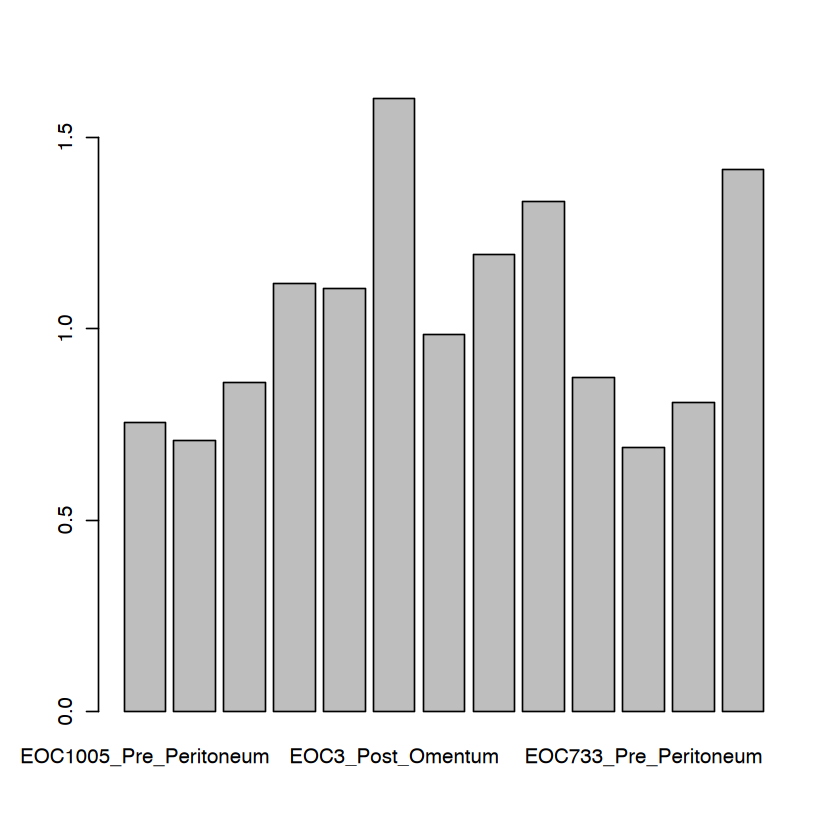

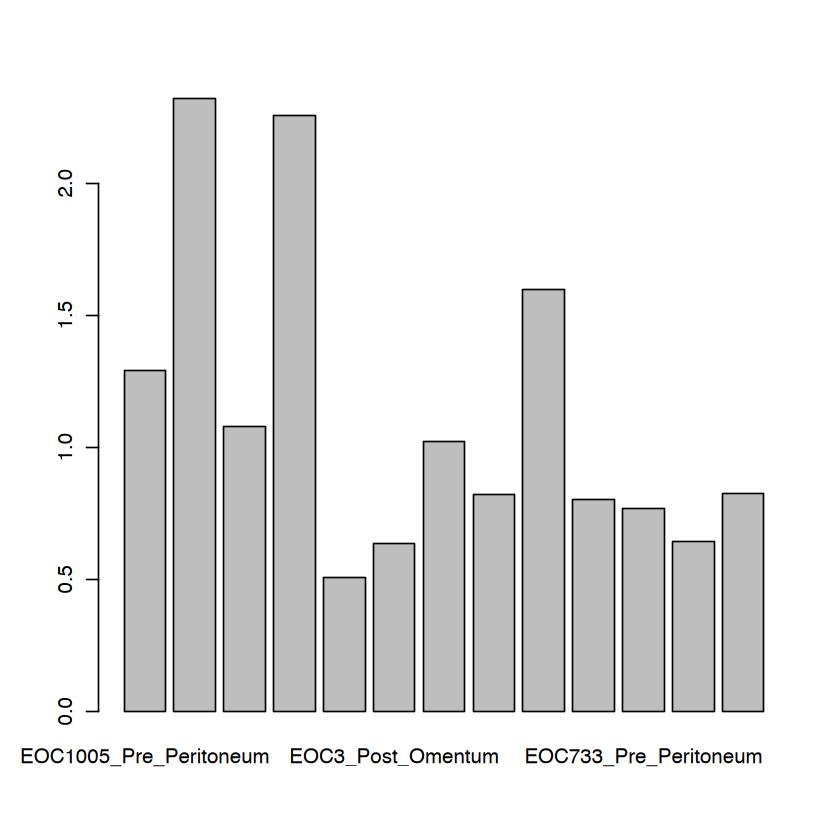

In [25]:
barplot(sizeFactors(dds_Bulk_SCMatched))
barplot(sizeFactors(dds_SC_SCMatched))

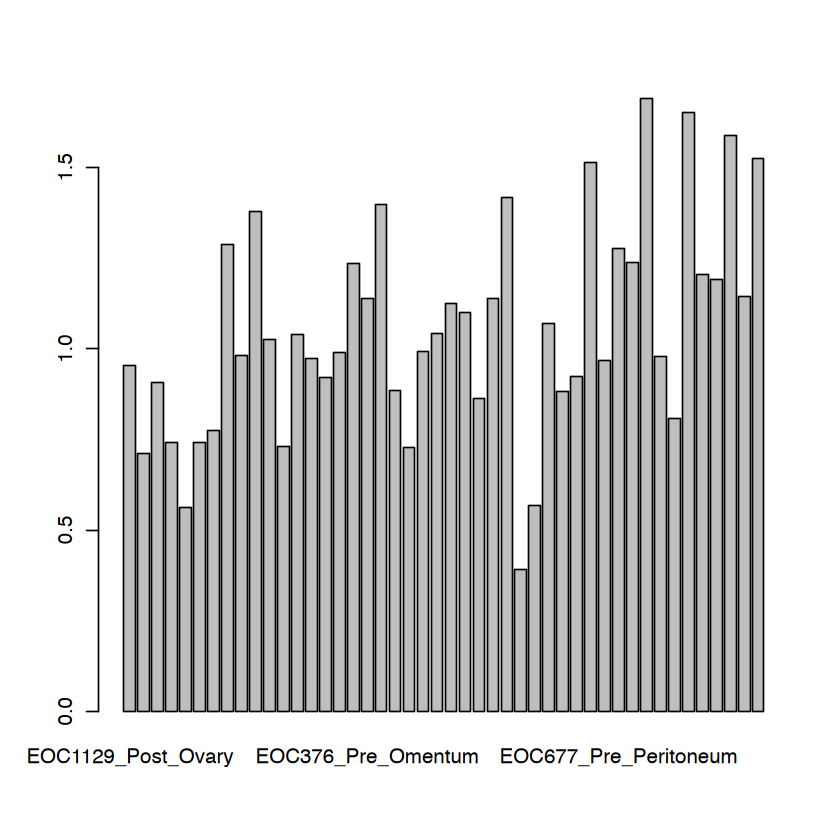

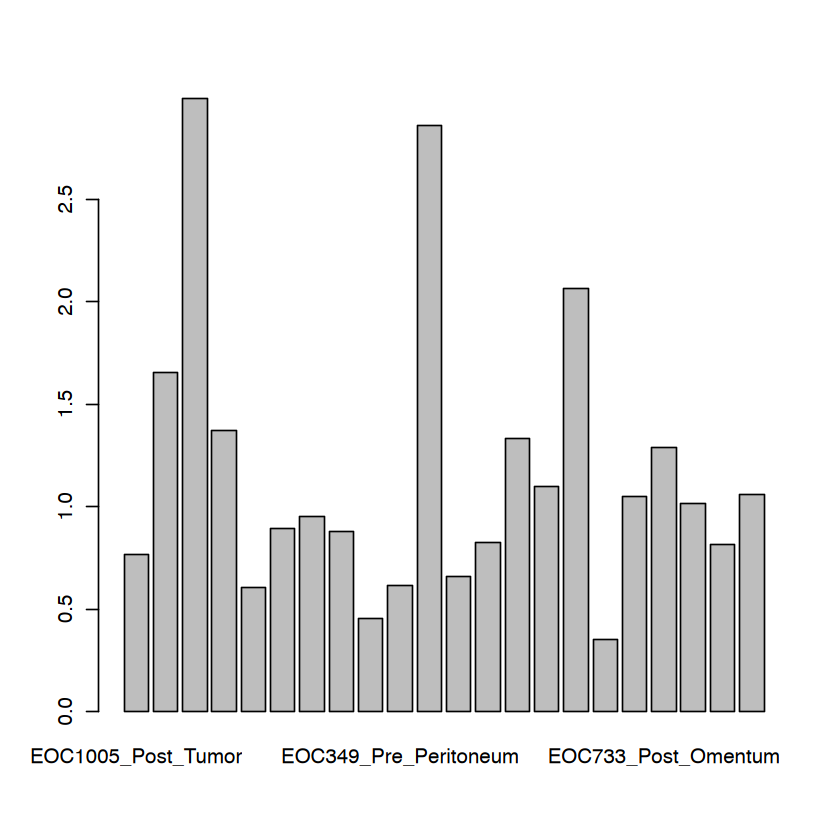

In [26]:
barplot(sizeFactors(dds_Bulk_Paired))
barplot(sizeFactors(dds_SC_Paired))

## 4. Calcualte Log2FC

In [38]:
Bulk_Paired_mat_MR[1:4,]

,EOC1129_Post_Ovary,EOC1129_Pre_Ovary,EOC1133_Post_Omentum,EOC1133_Pre_Peritoneum,EOC136_Post_Omentum,EOC136_Pre_Mesentery,EOC167_Post_Ascites,EOC167_Pre_Omentum,EOC183_Post_NA,EOC183_Pre_Mesentery,...,EOC740_Post_Ovary,EOC740_Pre_Peritoneum,EOC868_Post_Ovary,EOC868_Pre_Peritoneum,EOC87_Post_Peritoneum,EOC87_Pre_Peritoneum,EOC883_Post_Ascites,EOC883_Pre_Ascites,EOC933_Post_Mesentery,EOC933_Pre_Omentum
DDX11L1,1.047429,0.00000,1.100992,8.094694,1.774720,1.348192,3.874859,3.105931,7.137504,5.807400,...,4.843256,11.83059,1.020453,1.239452,0.000000,0.0000000,0.8388109,1.8904185,2.619741,2.625538
WASH7P,312.133799,18.25216,148.633891,183.479735,7.098878,8.089149,257.032333,153.743573,128.475073,94.370255,...,137.225581,237.20338,97.963520,130.142409,12.111236,11.6198047,9.2269204,27.7261384,147.578717,164.752534
MIR6859-1,2.094858,0.00000,22.019836,25.633198,0.000000,0.000000,18.082677,25.623929,7.137504,13.792576,...,20.180233,37.26637,7.143173,16.112870,3.027809,0.8299861,0.0000000,2.5205580,22.704418,21.660692
MIR1302-2HG,0.000000,0.00000,1.100992,1.349116,1.774720,0.000000,0.000000,0.000000,0.000000,0.725925,...,1.614419,0.00000,0.000000,0.000000,0.000000,0.8299861,0.0000000,0.6301395,0.000000,0.000000


In [42]:
#Bulk_Paired_mat_MR[1:2,]

calculate_log2FC <- function(mat) {
	mat_pseudocount <- mat + 1
	patient_names <- unique(str_split_fixed(colnames(mat), "_", 3)[,1])
	log2FC_list <- list()

	for (patient_name in patient_names) {
		post <- colnames(mat_pseudocount)[grepl(paste0("^", patient_name, "_Post_"), colnames(mat_pseudocount))]
		pre <- colnames(mat_pseudocount)[grepl(paste0("^", patient_name, "_Pre_"), colnames(mat_pseudocount))]
		log2FC_list[[patient_name]] <- log2(mat_pseudocount[, post] / mat_pseudocount[, pre])

	}

	log2FC_df <- as.matrix(as.data.table(log2FC_list))
	rownames(log2FC_df) <- rownames(mat_pseudocount)
	return(log2FC_df)
	}


Bulk_Paired_mat_MR_l2fc <- calculate_log2FC(Bulk_Paired_mat_MR)
Bulk_Paired_mat_cpm_l2fc <- calculate_log2FC(Bulk_Paired_mat_cpm)
SC_Paired_mat_MR_l2fc <- calculate_log2FC(SC_Paired_mat_MR)
SC_Paired_mat_cpm_l2fc <- calculate_log2FC(SC_Paired_mat_cpm)

In [47]:
shared_genes[1:5]

[1] "FAM87B"    "LINC00115" "LINC01128" "FAM41C"    "SAMD11"

In [49]:
Bulk_Paired_mat_MR_l2fc[c("HCN3", "FAM87B"),]
Bulk_Paired_mat_cpm_l2fc[c("HCN3", "FAM87B"),]

SC_Paired_mat_MR_l2fc[c("HCN3", "FAM87B"),]
SC_Paired_mat_cpm_l2fc[c("HCN3", "FAM87B"),]

,EOC1129,EOC1133,EOC136,EOC167,EOC183,EOC218,EOC26,EOC372,EOC376,EOC3,...,EOC568,EOC587,EOC60,EOC649,EOC677,EOC740,EOC868,EOC87,EOC883,EOC933
HCN3,1.359513,-0.9476683,-0.1445297,0.8710753,-0.4027525,-0.1959692,-1.5403002,0.00475132,-0.2288055,0.4707055,...,-0.6543048,0.7940378,-0.1395024,-1.939011,-1.194256,0.4422212,0.1043173,0.5041724,0.07429797,-2.12571762
FAM87B,2.529684,0.6802347,0.6829895,-1.7501281,0.3826654,-0.9352654,0.6860727,-0.67176414,0.6190366,0.2577647,...,0.1697334,-1.2290302,0.2183926,-0.494240,1.558446,-0.5206597,0.7640120,0.6303912,-1.38896948,-0.04184338


,EOC1129,EOC1133,EOC136,EOC167,EOC183,EOC218,EOC26,EOC372,EOC376,EOC3,...,EOC568,EOC587,EOC60,EOC649,EOC677,EOC740,EOC868,EOC87,EOC883,EOC933
HCN3,0.8584844,-0.4755667,-0.10710977,0.4475736,-0.587368403,-0.02198269,-1.300604,-0.3034001,-0.1168595,0.3761716,...,-0.615924157,0.3889798,-0.18437553,-1.6160812,-0.7658144,0.1315617,0.1178498,0.3736041,-0.1393531,-1.8840989
FAM87B,1.0394647,0.4091643,0.09737547,-0.8798186,0.002221534,-0.24565365,0.355421,-0.6187319,0.2115453,0.1113153,...,0.003154846,-0.4557671,0.06166952,-0.4407879,0.3977114,-0.4761185,0.4218725,0.1861878,-0.3541835,-0.1336313


,EOC1005,EOC136,EOC153,EOC227,EOC349,EOC372,EOC3,EOC443,EOC540,EOC733,EOC87
HCN3,-0.03133424,0.2352751,0.21181834,-1.436733,1.781945,0.2971316,-1.403434,-0.27955481,0.5088243,-1.01760188,-0.336068
FAM87B,1.20702714,-2.3856351,-0.07702085,2.053000,-2.090767,1.9840353,1.113046,-0.05731472,-0.1396061,-0.01692713,3.222051


,EOC1005,EOC136,EOC153,EOC227,EOC349,EOC372,EOC3,EOC443,EOC540,EOC733,EOC87
HCN3,-0.03171736,-0.001491882,0.09163371,-0.5638645,1.0786497,0.1244048,-0.3743377,-0.105110636,0.03576315,-0.31734316,-0.1983383
FAM87B,0.12698523,-0.582227016,0.01384385,0.2796881,-0.2560538,0.8480310,0.3372093,-0.008711411,-0.19682277,0.02557223,0.9551607


In [50]:
write.table(Bulk_Paired_mat_cpm_l2fc, file="../../data/l2fc_matrices/Bulk_Paired_l2fc_gencode_CPM.csv", quote=FALSE, sep=",")
write.table(SC_Paired_mat_cpm_l2fc, file="../../data/l2fc_matrices/SC_Paired_l2fc_gencode_CPM.csv", quote=FALSE, sep=",")

write.table(Bulk_Paired_mat_MR_l2fc, file="../../data/l2fc_matrices/Bulk_Paired_l2fc_gencode_MR.csv", quote=FALSE, sep=",")
write.table(SC_Paired_mat_MR_l2fc, file="../../data/l2fc_matrices/SC_Paired_l2fc_gencode_MR.csv", quote=FALSE, sep=",")